In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)

c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

In [3]:
# This notebook now depends on the provided Excel dataset
from ml.models import get_gbr


In [4]:
# Load dataset from Excel (data/dispersion_vs_L.xlsx)
data_path = os.path.join(ROOT, 'data', 'dispersion_full_dataset.xlsx')
if not os.path.exists(data_path):
    raise FileNotFoundError(f'Data file not found: {data_path}')
data = pd.read_excel(data_path)
# Features: kL and L
X = data[["kL", "L", "alpha1", "s", "P1", "P2"]].values

In [5]:
# Target: analytical phase velocity c / beta_l
y = data['c_beta'].values

In [6]:
# Scale features and split
X_scaled = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train GBR surrogate
model = get_gbr()
model.fit(Xtr, ytr)

# Evaluate
print('Test R^2:', model.score(Xte, yte))

Test R^2: 0.9998025083069491


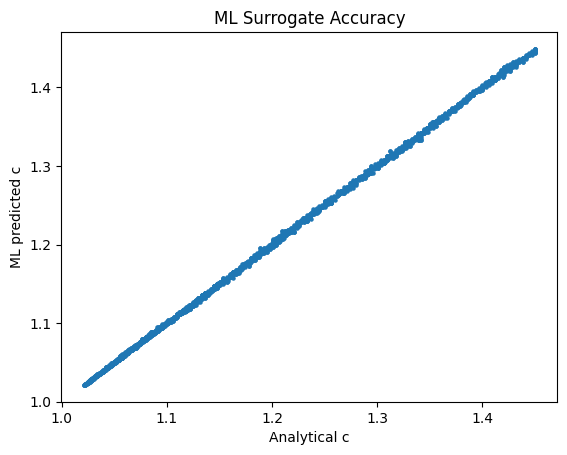

In [7]:
import matplotlib.pyplot as plt

pred = model.predict(Xte)

plt.scatter(yte, pred, s=5)
plt.xlabel("Analytical c")
plt.ylabel("ML predicted c")
plt.title("ML Surrogate Accuracy")
plt.show()

In [8]:
import os
print("Current Working Directory:", os.getcwd())

Current Working Directory: c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml\executed_notebooks


In [9]:
import os
from joblib import dump

ROOT = os.path.abspath("..")

model_path = os.path.join(ROOT, "data", "models", "gbr_model.pkl")
os.makedirs(os.path.dirname(model_path), exist_ok=True)

dump(model, model_path)

print("Saved at:", model_path)

Saved at: c:\Users\Public\workspace\sh-wave-ml-surrogate\classical_ml\data\models\gbr_model.pkl
